<a href="https://colab.research.google.com/github/shah-prog/AI-ML-Internship-Task/blob/main/TASK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance scikit-learn matplotlib pandas

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#yfinance → downloads stock data
#pandas → handles dataset (tables)
#matplotlib → makes graphs
#sklearn → machine learning tools

In [2]:
# Load data
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

# Show first rows
df.head()

/tmp/ipykernel_4935/2847971295.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


In [3]:
# “Take the Close column and move all values one step up, so each row now contains the next day's closing price”
df['Target'] = df['Close'].shift(-1)

# Drop last row (it will have NaN target)
df = df.dropna()

#Use today’s Open, High, Low, Volume (X) to predict tomorrow’s Close price (y)
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
# the dataset into training and testing sets (80%–20%) without changing the time order

In [5]:
model = LinearRegression()      # Create a Linear Regression model
model.fit(X_train, y_train)        #Train it using training data

LinearRegression()

In [6]:

y_pred = model.predict(X_test)   #Use the trained model to predict stock prices for the test data.


In [7]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

#Compare real values and predicted values, calculate average squared error, and display it

Mean Squared Error: 4.945948099168225


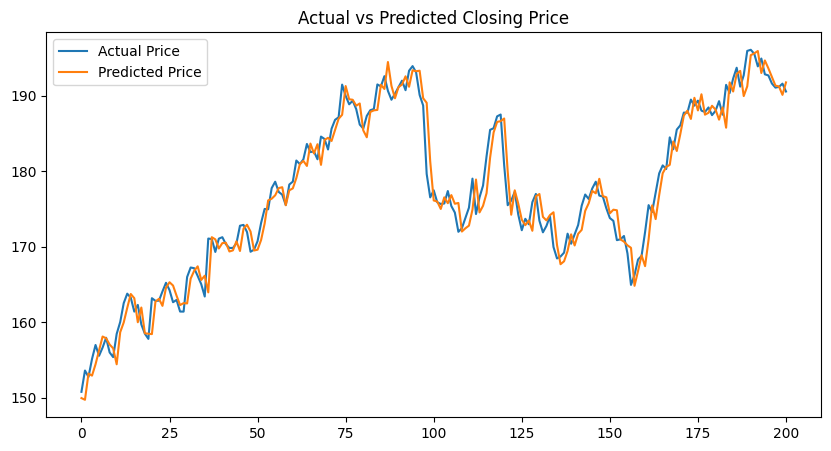

In [8]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Closing Price")
plt.show()

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("RF MSE:", mean_squared_error(y_test, rf_pred))

RF MSE: 103.410310159564
